In [1]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


#avoid warning messages
import warnings
warnings.filterwarnings('ignore')

# Exploratory Data Analysis (EDA)

***Phishing Website Detection Dataset:***

*   **having_IP_Address:** whether the URL uses an IP address instead of a domain name

*   **URL_Length:** length category of the URL

*   **Shortining_Service:** whether a URL shortening service is used

*   **having_At_Symbol:** whether the URL contains an '@' symbol

*   **double_slash_redirecting:** whether '//' appears later in the URL path

*   **Prefix_Suffix:** whether the domain contains a '-' symbol

*   **having_Sub_Domain:** number of sub-domains in the URL

*   **SSLfinal_State:** state of the SSL certificate used by the site

*   **Domain_registeration_length:** how long the domain has been registered for

*   **Favicon:** whether the favicon is loaded from an external domain

*   **port:** whether non-standard ports are open

*   **HTTPS_token:** whether 'https' appears misleadingly in the domain part of the URL

*   **Request_URL:** whether external objects are loaded from a different domain

*   **URL_of_Anchor:** percentage of anchor tags linking to a different domain

*   **Links_in_tags:** percentage of \<meta\>, \<script\>, \<link\> tags pointing outside the domain

*   **SFH:** whether the Server Form Handler is empty or points elsewhere

*   **Submitting_to_email:** whether the form submits data via a mail() function

*   **Abnormal_URL:** whether the domain matches the host name in the WHOIS record

*   **Redirect:** number of page redirects

*   **on_mouseover:** whether onMouseOver changes the status bar

*   **RightClick:** whether right-click is disabled

*   **popUpWidnow:** whether pop-up windows with text fields are used

*   **Iframe:** whether an invisible iframe is used

*   **age_of_domain:** age of the domain in months

*   **DNSRecord:** whether a DNS record exists for the domain

*   **web_traffic:** website traffic rank

*   **Page_Rank:** page rank value

*   **Google_Index:** whether the page is indexed by Google

*   **Links_pointing_to_page:** number of links pointing to the page

*   **Statistical_report:** whether the host/IP is flagged in known phishing statistical reports

*   **Result [Target column]:**

          1  = legitimate
         -1  = phishing


In [2]:
# read dataset from a public Google Drive File

file_link = 'https://drive.google.com/file/d/1-uViZav14R7byp5D1_t6R_MqTkylwXd0/view?usp=drive_link'

# get the id part of the file
id = file_link.split("/")[-2]

# creating a new link using the id for better readability of csv file in pandas
new_link = f'https://drive.google.com/uc?id={id}'
df = pd.read_csv(new_link)

# let's look at the first few instances
df.head()

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [3]:
df.shape

(11055, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL                  11055 non-null  int64
 13  URL_of_Anchor                11055 non-null  i

In [5]:
df.describe(include='all')

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,0.313795,-0.633198,0.738761,0.700588,0.741474,-0.734962,0.063953,0.250927,-0.336771,0.628584,...,0.613388,0.816915,0.061239,0.377114,0.287291,-0.483673,0.721574,0.344007,0.719584,0.113885
std,0.949534,0.766095,0.673998,0.713598,0.671011,0.678139,0.817518,0.911892,0.941629,0.777777,...,0.789818,0.576784,0.998168,0.926209,0.827733,0.875289,0.692369,0.569944,0.694437,0.993539
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
df.nunique()

,0
having_IP_Address,2
URL_Length,3
Shortining_Service,2
having_At_Symbol,2
double_slash_redirecting,2
Prefix_Suffix,2
having_Sub_Domain,3
SSLfinal_State,3
Domain_registeration_length,2
Favicon,2


In [7]:
df.isnull().sum()

,0
having_IP_Address,0
URL_Length,0
Shortining_Service,0
having_At_Symbol,0
double_slash_redirecting,0
Prefix_Suffix,0
having_Sub_Domain,0
SSLfinal_State,0
Domain_registeration_length,0
Favicon,0


In [8]:
cat_cols=df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
[]
Numerical Variables:
['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']


Result
 1    6157
-1    4898
Name: count, dtype: int64


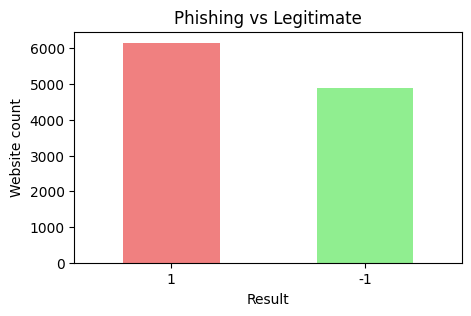

In [9]:
# Visualize the distribution of the 'Result' variable

print(df.value_counts('Result'))

plt.figure(figsize=(5, 3))
df['Result'].value_counts().plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title('Phishing vs Legitimate')
plt.xlabel('Result')
plt.ylabel('Website count')
plt.xticks(rotation = 0)
plt.show()

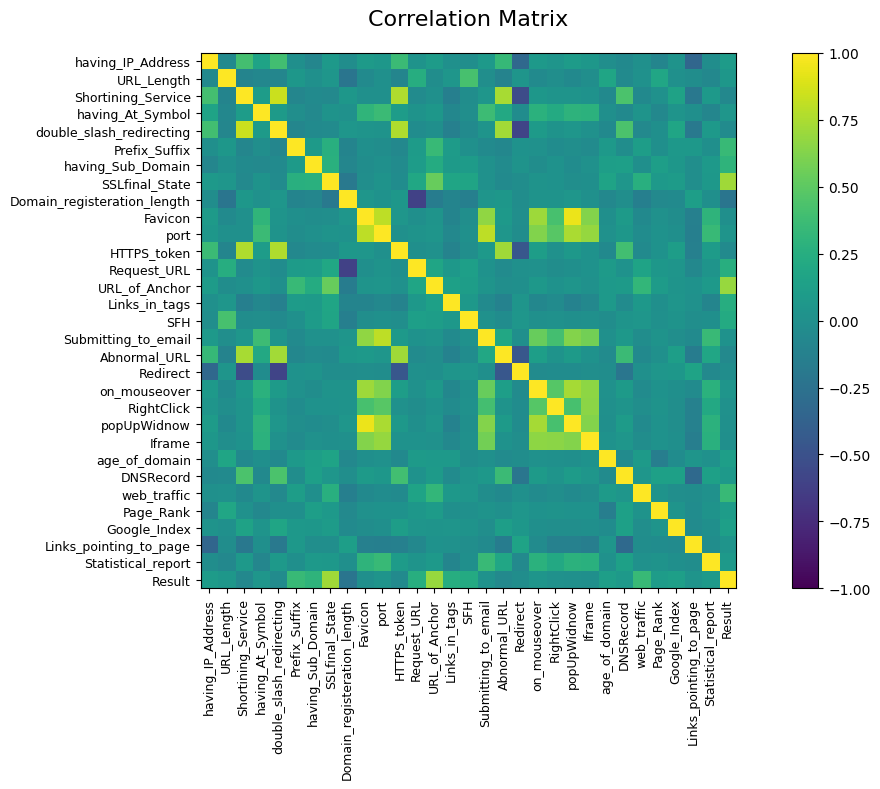

In [10]:
correlation_matrix = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 8))

cax = ax.imshow(correlation_matrix, cmap="viridis", vmin=-1, vmax=1)

ax.set_title("Correlation Matrix", fontsize=16, pad=20)

ax.set_xticks(np.arange(len(correlation_matrix.columns)))
ax.set_yticks(np.arange(len(correlation_matrix.columns)))

ax.set_xticklabels(correlation_matrix.columns, rotation=90, fontsize=9)
ax.set_yticklabels(correlation_matrix.columns, fontsize=9)

fig.colorbar(cax)
plt.tight_layout()
plt.show()

# Data Preprocessing

In [11]:
#drop duplicates
df = df.drop_duplicates()
df

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11037,1,-1,-1,1,-1,-1,-1,-1,-1,1,...,1,1,1,-1,0,-1,1,0,1,-1
11045,1,-1,1,1,1,-1,1,-1,-1,1,...,1,1,1,1,0,-1,1,0,1,1
11048,1,-1,1,1,1,-1,-1,1,1,1,...,1,1,1,1,0,-1,1,0,1,1
11049,-1,-1,1,1,-1,-1,1,-1,1,1,...,1,1,-1,1,1,-1,1,1,1,-1


In [12]:
df.shape

(5849, 31)

In [13]:
#check for total null value for each feature
df.isnull().sum()

,0
having_IP_Address,0
URL_Length,0
Shortining_Service,0
having_At_Symbol,0
double_slash_redirecting,0
Prefix_Suffix,0
having_Sub_Domain,0
SSLfinal_State,0
Domain_registeration_length,0
Favicon,0


In [14]:
#check for categorical and numerical variables in df
cat_cols=df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
[]
Numerical Variables:
['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']


In [15]:
#converting target labels from {-1, 1} to {0, 1}
df['Result'] = df['Result'].replace({-1: 0, 1: 1})
df.head()

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,0
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,0
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,0
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,0
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [16]:
df.shape

(5849, 31)

In [17]:
# Split the data into 80-20 train-test split (you can do other ratios as well)
X = df.drop(['Result'], axis=1)
y = df['Result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
# display the shapes

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4679, 30)
X_test shape: (1170, 30)
y_train shape: (4679,)
y_test shape: (1170,)


# Principal Component Analysis (PCA)

The phishing dataset has 30 input features. PCA is applied here to see how much of that information is redundant, and whether the 2 legitimate/phishing classes separate along the top principal components.

In [19]:
#standardizing features before PCA (PCA is scale sensitive)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_pca = StandardScaler()
X_train_scaled_pca = scaler_pca.fit_transform(X_train)
X_test_scaled_pca = scaler_pca.transform(X_test)

In [20]:
#fitting PCA with all components to inspect explained variance
pca_full = PCA()
X_train_pca_full = pca_full.fit_transform(X_train_scaled_pca)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

variance_df = pd.DataFrame({
    "Principal Component": [f"PC{i}" for i in range(1, len(explained_variance_ratio) + 1)],
    "Explained Variance (%)": explained_variance_ratio * 100,
    "Cumulative Variance (%)": cumulative_variance * 100
})

variance_df.round(4)

,Principal Component,Explained Variance (%),Cumulative Variance (%)
0,PC1,17.6198,17.6198
1,PC2,13.1190,30.7388
2,PC3,8.2502,38.9891
3,PC4,5.2376,44.2267
4,PC5,4.8695,49.0962
5,PC6,4.0230,53.1192
6,PC7,3.7193,56.8385
7,PC8,3.6305,60.4690
8,PC9,3.4678,63.9368
9,PC10,3.2804,67.2172


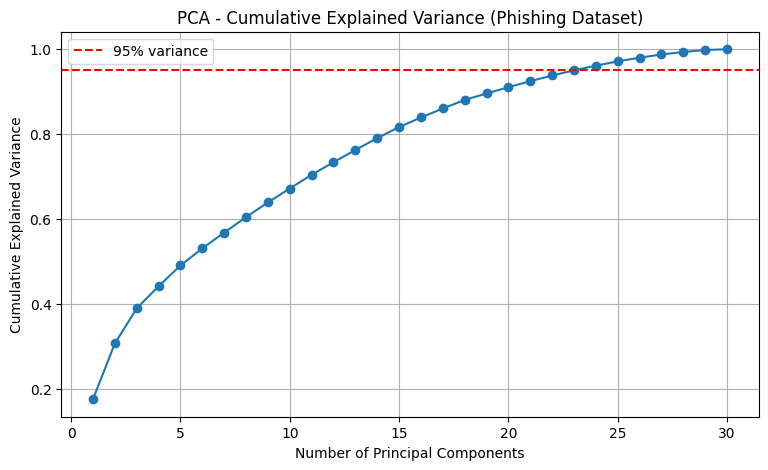

Components needed to retain 95% variance: 23


In [21]:
#scree plot - cumulative variance vs number of components
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance (Phishing Dataset)")
plt.legend()
plt.grid()
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print("Components needed to retain 95% variance:", n_components_95)

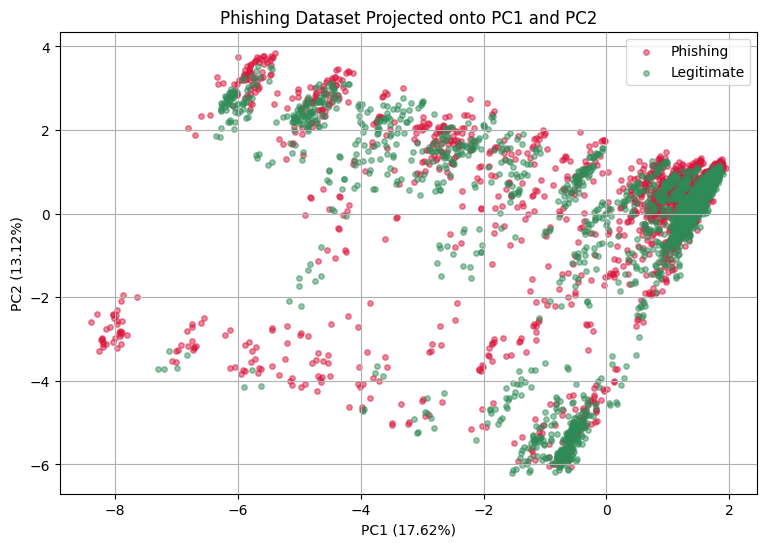

In [22]:
#projecting onto the first 2 principal components, colored by class
pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_scaled_pca)

plt.figure(figsize=(9, 6))
for label, name, color in [(0, "Phishing", "crimson"), (1, "Legitimate", "seagreen")]:
    mask = y_train == label
    plt.scatter(X_train_pca_2d[mask, 0], X_train_pca_2d[mask, 1], label=name, alpha=0.5, s=15, color=color)

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.2f}%)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.2f}%)")
plt.title("Phishing Dataset Projected onto PC1 and PC2")
plt.legend()
plt.grid()
plt.show()

In [23]:
#comparing a classifier trained on all 30 features vs the PCA-reduced features
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

pca_95 = PCA(n_components=n_components_95)
X_train_pca = pca_95.fit_transform(X_train_scaled_pca)
X_test_pca = pca_95.transform(X_test_scaled_pca)

model_rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf_baseline.fit(X_train, y_train)
acc_rf_baseline = accuracy_score(y_test, model_rf_baseline.predict(X_test))

model_rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf_pca.fit(X_train_pca, y_train)
acc_rf_pca = accuracy_score(y_test, model_rf_pca.predict(X_test_pca))

print(f"Random Forest Accuracy (all 30 original features): {acc_rf_baseline:.4f}")
print(f"Random Forest Accuracy ({n_components_95} PCA components): {acc_rf_pca:.4f}")

Random Forest Accuracy (all 30 original features): 0.9419
Random Forest Accuracy (23 PCA components): 0.9239


# Model Training

## Logistic Regression

In [24]:
#library implementation of logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", acc_lr)
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9128205128205128
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       604
           1       0.90      0.92      0.91       566

    accuracy                           0.91      1170
   macro avg       0.91      0.91      0.91      1170
weighted avg       0.91      0.91      0.91      1170



## K-Nearest Neighbors (KNN)

In [25]:
#KNN is distance based, so scale the features first
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", acc_knn)
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.9188034188034188
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       604
           1       0.92      0.91      0.92       566

    accuracy                           0.92      1170
   macro avg       0.92      0.92      0.92      1170
weighted avg       0.92      0.92      0.92      1170



In [26]:
#checking a few different k values
for k in [3, 5, 7, 9, 11]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    print(f"k={k}: accuracy={accuracy_score(y_test, pred):.4f}")

k=3: accuracy=0.9128
k=5: accuracy=0.9188
k=7: accuracy=0.9171
k=9: accuracy=0.9231
k=11: accuracy=0.9171


## Decision Tree

In [27]:
#library implementation of decision tree
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(max_depth=10, random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", acc_dt)
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9341880341880342
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       604
           1       0.95      0.92      0.93       566

    accuracy                           0.93      1170
   macro avg       0.93      0.93      0.93      1170
weighted avg       0.93      0.93      0.93      1170



## Random Forest

In [28]:
#library implementation of random forest
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9418803418803419
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       604
           1       0.94      0.94      0.94       566

    accuracy                           0.94      1170
   macro avg       0.94      0.94      0.94      1170
weighted avg       0.94      0.94      0.94      1170



## Neural Network (MLP)

In [29]:
#library implementation of a simple feedforward neural network
from sklearn.neural_network import MLPClassifier

model_nn = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)
model_nn.fit(X_train_scaled, y_train)
y_pred_nn = model_nn.predict(X_test_scaled)

acc_nn = accuracy_score(y_test, y_pred_nn)
print("Neural Network Accuracy:", acc_nn)
print(classification_report(y_test, y_pred_nn))

Neural Network Accuracy: 0.9264957264957265
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       604
           1       0.92      0.93      0.92       566

    accuracy                           0.93      1170
   macro avg       0.93      0.93      0.93      1170
weighted avg       0.93      0.93      0.93      1170



## Softmax (Multinomial) Regression

`LogisticRegression` fits the model using the softmax function when there are multiple classes (with the `lbfgs` solver, this is automatic in current scikit-learn versions, replacing the older `multi_class` parameter). Result is binary here, so this coincides closely with the earlier Logistic Regression result, but the formulation is the same one used for multi-class problems.

In [30]:
#library implementation of softmax regression
#note: sklearn's LogisticRegression uses the softmax formulation automatically
#with the lbfgs solver (the multi_class parameter was removed in newer sklearn versions)
model_softmax = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
model_softmax.fit(X_train_scaled, y_train)
y_pred_softmax = model_softmax.predict(X_test_scaled)

acc_softmax = accuracy_score(y_test, y_pred_softmax)
print("Softmax Regression Accuracy:", acc_softmax)
print(classification_report(y_test, y_pred_softmax))

Softmax Regression Accuracy: 0.9128205128205128
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       604
           1       0.90      0.92      0.91       566

    accuracy                           0.91      1170
   macro avg       0.91      0.91      0.91      1170
weighted avg       0.91      0.91      0.91      1170



## Model Comparison

                 Model  Accuracy
3        Random Forest  0.941880
2        Decision Tree  0.934188
4       Neural Network  0.926496
1                  KNN  0.918803
0  Logistic Regression  0.912821
5   Softmax Regression  0.912821


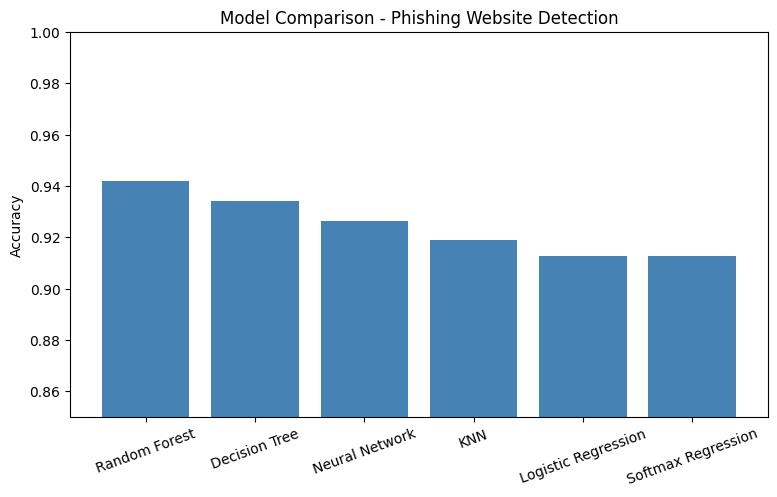

In [31]:
#comparing accuracy across all 6 models
results = {
    "Logistic Regression": acc_lr,
    "KNN": acc_knn,
    "Decision Tree": acc_dt,
    "Random Forest": acc_rf,
    "Neural Network": acc_nn,
    "Softmax Regression": acc_softmax
}

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"]).sort_values("Accuracy", ascending=False)
print(results_df)

plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["Accuracy"], color='steelblue')
plt.ylabel("Accuracy")
plt.title("Model Comparison - Phishing Website Detection")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=20)
plt.show()

### Precision vs Recall

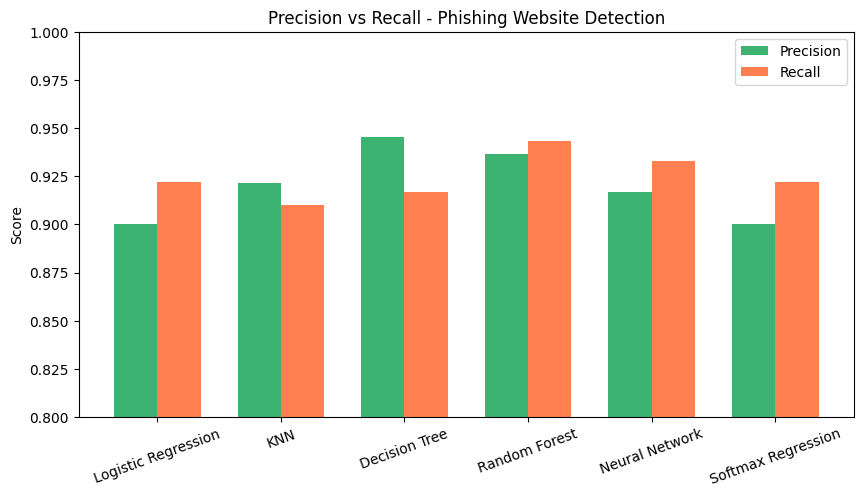

In [32]:
from sklearn.metrics import precision_score, recall_score

precisions = {
    "Logistic Regression": precision_score(y_test, y_pred_lr),
    "KNN": precision_score(y_test, y_pred_knn),
    "Decision Tree": precision_score(y_test, y_pred_dt),
    "Random Forest": precision_score(y_test, y_pred_rf),
    "Neural Network": precision_score(y_test, y_pred_nn),
    "Softmax Regression": precision_score(y_test, y_pred_softmax)
}
recalls = {
    "Logistic Regression": recall_score(y_test, y_pred_lr),
    "KNN": recall_score(y_test, y_pred_knn),
    "Decision Tree": recall_score(y_test, y_pred_dt),
    "Random Forest": recall_score(y_test, y_pred_rf),
    "Neural Network": recall_score(y_test, y_pred_nn),
    "Softmax Regression": recall_score(y_test, y_pred_softmax)
}

models_list = list(precisions.keys())
x = np.arange(len(models_list))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, [precisions[m] for m in models_list], width, label='Precision', color='mediumseagreen')
plt.bar(x + width/2, [recalls[m] for m in models_list], width, label='Recall', color='coral')
plt.xticks(x, models_list, rotation=20)
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.title("Precision vs Recall - Phishing Website Detection")
plt.legend()
plt.show()

### Confusion Matrices

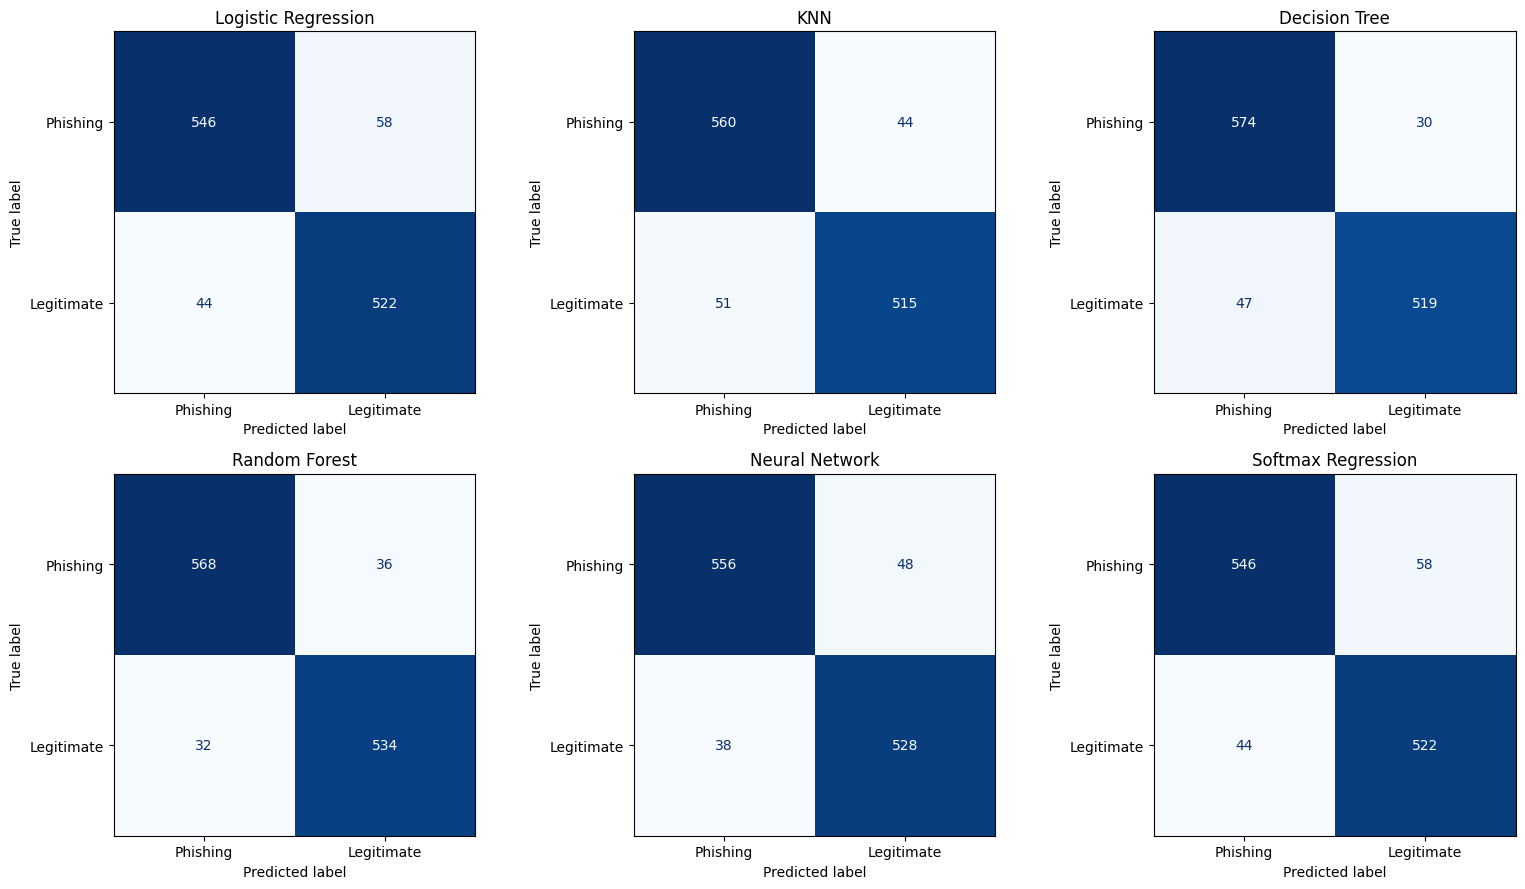

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds = {
    "Logistic Regression": y_pred_lr,
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Neural Network": y_pred_nn,
    "Softmax Regression": y_pred_softmax
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Phishing", "Legitimate"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

### ROC Curve Comparison

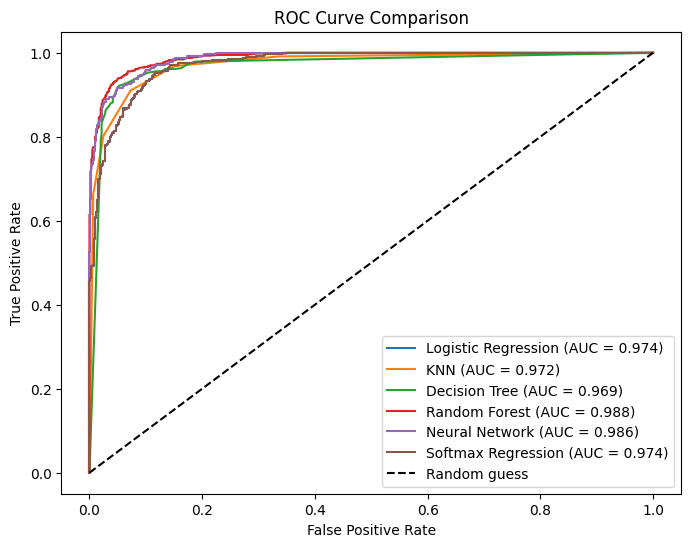

In [34]:
from sklearn.metrics import roc_curve, auc

proba = {
    "Logistic Regression": model_lr.predict_proba(X_test)[:, 1],
    "KNN": model_knn.predict_proba(X_test_scaled)[:, 1],
    "Decision Tree": model_dt.predict_proba(X_test)[:, 1],
    "Random Forest": model_rf.predict_proba(X_test)[:, 1],
    "Neural Network": model_nn.predict_proba(X_test_scaled)[:, 1],
    "Softmax Regression": model_softmax.predict_proba(X_test_scaled)[:, 1]
}

plt.figure(figsize=(8, 6))
for name, y_score in proba.items():
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()